Building optimized executable...
Running trajectories...


Running backend with UseDisplacement = Yes
Trajectory [300/300] completed, average time: 0.014 seconds.


Building optimized executable...
Running trajectories...


Running backend with UseDisplacement = No
Trajectory [300/300] completed, average time: 0.172 seconds.


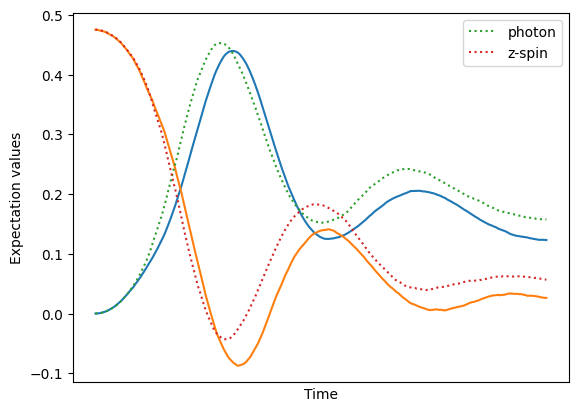

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pimcs import jspin, destroy, Dicke, rotated_qubits, mcsolve

output = []

for tol, disable_displ, truncation, ls in [(0.05, False, 4, '-'), (0.05, True, 60, ':')]:
    # setup system in exactly same way as with qutip.piqs
    N = 50
    OmegaC = 0
    OmegaA = 0.1/2
    Coupling = 0.1 / np.sqrt(N)
    
    a = destroy(truncation)
    
    Jz = jspin(N, 'z')
    Jp = jspin(N, '+')
    Jm = jspin(N, '-')
    
    H = OmegaC * a.dag()*a + OmegaA * 2*Jz + Coupling * (Jp * a + Jm * a.dag())
    system = Dicke(N, H, cavity_loss = 0.01, dephasing = 0.01)
    
    psi0 = rotated_qubits(N, 0.1 * np.pi)
    times = np.linspace(0, 128, 300)
    
    data = mcsolve(
        system,
        psi0,               # initial state of simulations
        times,              # times to output expecation values (must be linearly spaced for now)
        [a.dag()*a, a, Jz], # operators of expectation values to output
        ntraj = 300,        # number of Monte Carlo simulations to run 
        ncpu = 8,           # number of simulations to run in parallel (ideally = number of CPU cores)
        jtol = tol,         # parameter to tune integration step size (lower is more accurate but slower)
        disable_displ = disable_displ,
    )

    plt.plot(times, data.expect[0].real / N, ls = ls, label = "photon" if ls == ':' else None)
    plt.plot(times, data.expect[2].real / N, ls = ls, label = "z-spin" if ls == ':' else None)

plt.xticks([])
plt.xlabel("Time")
plt.ylabel("Expectation values")
plt.legend(loc = "upper right");